In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra


In [2]:
data = pd.read_csv("~/github/clipnet_k562/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [57]:
data["pred"] = np.log2(data["ref"] / data["alt"])
data["pred_p"] = np.log2(data["ref_p"] / data["alt_p"])
data = data[np.isfinite(data["pred"])]
data.dropna(inplace=True)
data = data[data.emVar_K562 == 1]

pearsons = [
    pearsonr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred"])[0]
    for fold in range(10)
]
spearmans = [
    spearmanr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred"])[0]
    for fold in range(10)
]

pearsons_p = [
    pearsonr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred_p"])[0]
    for fold in range(10)
]
spearmans_p = [
    spearmanr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred_p"])[0]
    for fold in range(10)
]

sign_correct = [
    (np.sign(data[data["fold"] == fold]["expt"]) == np.sign(data[data["fold"] == fold]["pred"])).mean()
    for fold in range(10)
]
sign_correct_p = [
    (np.sign(data[data["fold"] == fold]["expt"]) == np.sign(data[data["fold"] == fold]["pred_p"])).mean()
    for fold in range(10)
]


In [58]:
sign_correct

[0.7085181898846495,
 0.6384742951907131,
 0.6409017713365539,
 0.6382411725516323,
 0.6828992072480181,
 0.632258064516129,
 0.6485117162761241,
 0.6335504885993485,
 0.6885899352267065,
 0.6556603773584906]

In [59]:
sign_correct_p

[0.5532386867790594,
 0.542841348811498,
 0.5614600107353731,
 0.5649566955363091,
 0.5770101925254814,
 0.5419354838709678,
 0.5598480050664978,
 0.5396308360477742,
 0.5381165919282511,
 0.5489386792452831]

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<Axes: xlabel='expt', ylabel='pred_p'>

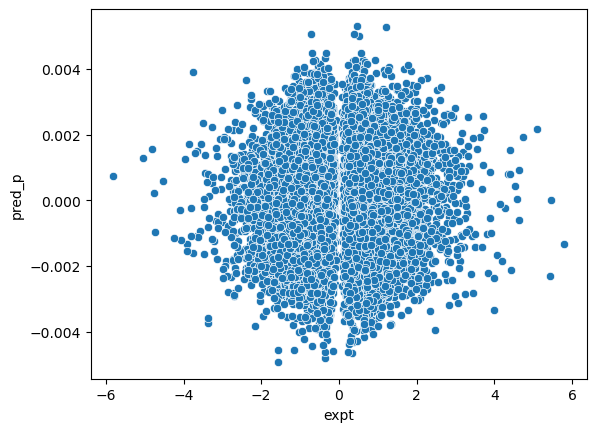

In [36]:
sns.scatterplot(data["expt"], data["pred_p"])

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<Axes: xlabel='expt', ylabel='pred'>

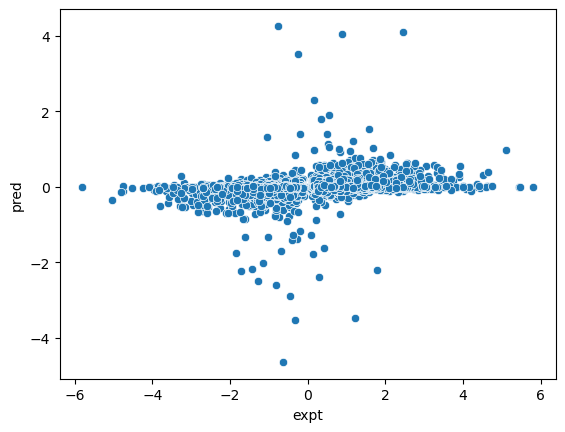

In [38]:
sns.scatterplot(data["expt"], data["pred"])

0.6613647401651287

In [40]:
((data["pred_p"] > 0) == (data["expt"] > 0)).mean()

0.5533632831471588

In [44]:
pearsons

[0.5119878596383289,
 0.3913978449728768,
 0.42244589484266476,
 0.39589214820843943,
 0.46313046919356504,
 0.3608130351183288,
 0.41229038482543856,
 0.3311444132375651,
 0.4983257516401296,
 0.41166034006903196]

In [42]:
pearsons_p

[0.08235775139777032,
 0.07469123685618621,
 0.07701323136531808,
 0.10223339838804962,
 0.1360391615533801,
 -0.03896189510905488,
 0.09839790095174063,
 0.05975632283905737,
 0.08019910189960154,
 0.08115724897191176]